> # ME630 -Assignment 1 - Problem Statement 1

**Name:** Meghaj Nandumar Barhate  
**Programme:** M.Tech. in Fluid and Thermal Sciences  
**Roll Number:** 261050047 

# Rectangular Plate: Steady-State Heat Conduction
A thin rectangular plate of width $a$ and height $b$ has three sides held at $0^\circ\mathrm{C}$ while the fourth (top) side is held at a uniform temperature $T_0$. There is no internal heat generation and the plate is thin enough that conduction may be treated as two-dimensional, so that the steady-state temperature field satisfies Laplace's equation
$$
\frac{\partial^2 T}{\partial x^2}
+
\frac{\partial^2 T}{\partial y^2}
=0,
\qquad
0 \le x \le a,
\qquad
0 \le y \le b.
$$

#### Boundary Conditions
$$
T(x,0)=0,
\qquad
T(0,y)=0,
\qquad
T(a,y)=0,
\qquad
T(x,b)=T_0.
$$

#### Data
$$
a=0.4\ \mathrm{m},
\qquad
b=0.2\ \mathrm{m},
\qquad
T_0=100^\circ\mathrm{C}.
$$

#### Analytical Solution
By separation of variables,
$$
T(x,y)
=
\frac{4T_0}{\pi}
\sum_{n=1,3,5,\ldots}^{\infty}
\frac{1}{n}
\sin\left(\frac{n\pi x}{a}\right)
\frac{
\sinh\left(\frac{n\pi y}{a}\right)
}{
\sinh\left(\frac{n\pi b}{a}\right)
}.
$$
Use enough terms to ensure the series has converged to at least **five significant figures** before using it as your benchmark.

---

**Fig. 1:** Rectangular plate with three sides at $0^\circ\mathrm{C}$ and the top side at $T_0$; inset shows the interior 5-point stencil at node $(i,j)$.

---

## Tasks
> #### Derive the standard **5-point finite-difference equation** at an interior node, and assemble the global linear system
$$
[A]\{T\}=\{b\}
$$
for a uniform grid with
$$
\Delta x = \Delta y = h.
$$
---
> #### Solve the system using a **direct method** (Gaussian elimination or LU decomposition). Record the **CPU time** and **memory used** as the grid is refined:
$$
h = 0.02,\; 0.01,\; 0.005\ \mathrm{m}.
$$
---
> #### Solve the same system using:
- Jacobi
- Gauss-Seidel
- SOR
For SOR, try at least three values of the relaxation factor $\omega$, including the theoretical optimum for a rectangular Dirichlet problem.
Record the **number of iterations** and **CPU time** for each method.
---
> #### Compare all solutions with the analytical series at the points
$$
\left(\frac{a}{4},\frac{b}{2}\right),
\qquad
\left(\frac{a}{2},\frac{b}{2}\right),
\qquad
\left(\frac{3a}{4},\frac{b}{2}\right),
\qquad
\left(\frac{a}{2},\frac{3b}{4}\right).
$$

Tabulate the **maximum absolute error** versus $h$ and confirm the expected accuracy of the 5-point scheme.
$$
O(h^2)
$$

---
> #### Summarize, in a short paragraph, how solution time scales with the number of unknowns N for the direct method versus each iterative method, and recommend a solver for this problem class
---
---
## *Numerical Methods Project Requirements*
#### 1. Discretization Derivation
Derive the finite-difference (or control-volume) discretization from first principles **before** writing any code.

#### 2. Analytical Validation
Wherever an analytical solution is given, validate your numerical solution against it at several interior points and report the **maximum absolute and percentage errors**, not just a visual comparison of plots.

#### 3. Linear System Solution
Solve the linear system $[A]\{T\} = \{b\}$ by:

- **(i) Direct method**: Gaussian elimination / LU decomposition, exploiting bandedness where possible.
- **(ii) Iterative methods**: Jacobi, Gauss–Seidel, and SOR, as specified in each problem.

For each method, report:
- Number of iterations
- Wall-clock time
- Memory footprint (as the grid is refined)

Then discuss which approach you would recommend and why.

> **Note**: Problem 3 instead uses a Picard/Newton iteration around a tridiagonal solve, and Problem 4 may be solved by any method consistent with its own tasks.

#### 4. Grid-Refinement (Convergence) Study
Perform a grid-refinement study for **every** problem. Use at least three grid sizes, with error plotted or tabulated against $\Delta x$, $\Delta r$, or $\Delta \theta$ as appropriate.

#### 5. Convergence Criteria and Parameters
State all of the following clearly:
- Convergence criteria (e.g., $\max |T^{p+1} - T^p| < 10^{-6}$)
- Initial guesses used
- Relaxation factors used (for SOR or other iterative methods)



## Import Libraries

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import lu_factor, lu_solve
import os
import time as t
%pip install -qq numpy scipy matplotlib psutil ipympl
%matplotlib widget
%matplotlib widget
from pathlib import Path
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

Note: you may need to restart the kernel to use updated packages.


## Generate Problem Statement Schematic (Figure 1)

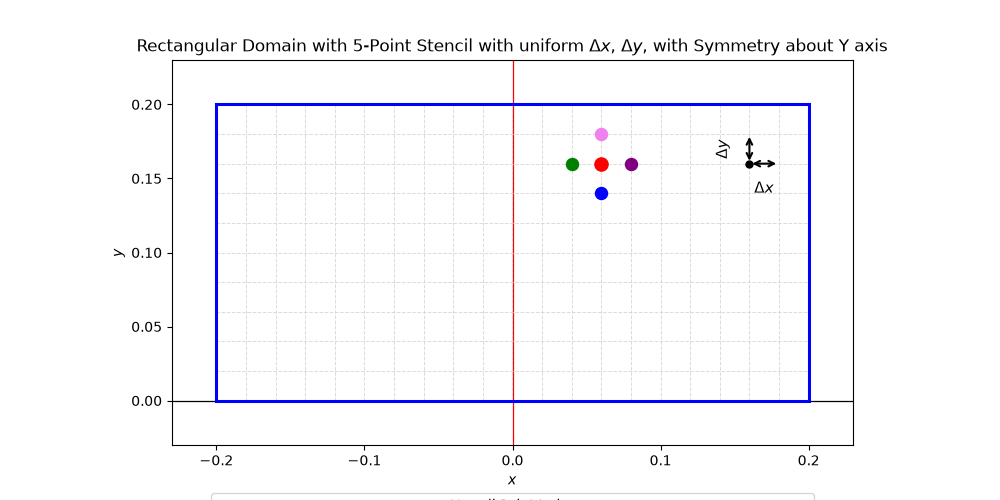

In [4]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Geometry
# ------------------------------------------------------------
length = 0.4
breadth = 0.2
#Placeholder for Graphical representation of the domain and the stencil points
dx = 0.02
dy = 0.02
y_shift = 0.1

#Problem has 1 Axis of Symmetry, so we can use half the domain for the simulation. The other half can be obtained by mirroring the results.
xmin, xmax = -length / 2, length / 2
ymin_ref, ymax_ref =0.0 , breadth
ymin, ymax = ymin_ref , ymax_ref

# ------------------------------------------------------------
# Mesh coordinates
# ------------------------------------------------------------
x_grid = np.arange(xmin, xmax + 1e-12, dx)
y_grid = np.arange(ymin_ref, ymax_ref + 1e-12, dy) + y_shift

# ------------------------------------------------------------
# Stencil points measured from the origin
# ------------------------------------------------------------
points = {
    "(i,j)": (3 * dx, 3 * dy + y_shift),     # red
    "(i,j-1)": (3 * dx, 2 * dy + y_shift),   # blue
    "(i,j+1)": (3 * dx, 4 * dy + y_shift),   # violet
    "(i-1,j)": (2 * dx, 3 * dy + y_shift),   # green
    "(i+1,j)": (4 * dx, 3 * dy + y_shift),   # purple
}

# ------------------------------------------------------------
# Location to move delta x and delta y arrows: grid point (8,3)
# ------------------------------------------------------------
base_x = 8 * dx
base_y = 3 * dy + y_shift

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# Faint light-grey dashed mesh
for x in x_grid:
    ax.plot([x, x], [ymin , ymax], linestyle="--", linewidth=0.7, color="lightgrey", alpha=0.8, zorder=1)

for y in y_grid:
    ax.plot([xmin, xmax], [y - y_shift, y - y_shift], linestyle="--", linewidth=0.7, color="lightgrey", alpha=0.8, zorder=1)

# Rectangle boundary in LaTeX blue
ax.add_patch(Rectangle((xmin, ymin), length, breadth, fill=False, edgecolor="#0000FF", linewidth=2.2, zorder=2))

# Cartesian axes through origin
ax.axhline(0, color="black", linewidth=0.9, zorder=0)
ax.axvline(0, color="Red", linewidth=0.9, zorder=0)

# ------------------------------------------------------------
# Stencil points
# ------------------------------------------------------------
ax.scatter(*points["(i,j)"], s=90, color="red", zorder=5)
ax.scatter(*points["(i,j-1)"], s=75, color="#0000FF", zorder=5)
ax.scatter(*points["(i,j+1)"], s=75, color="violet", zorder=5)
ax.scatter(*points["(i-1,j)"], s=75, color="green", zorder=5)
ax.scatter(*points["(i+1,j)"], s=75, color="purple", zorder=5)

# Mark the reference location (8,3)
ax.scatter(base_x, base_y, s=25, color="black", zorder=6)

# ------------------------------------------------------------
# Move delta x and delta y arrows to grid point (8,3)
# ------------------------------------------------------------
ax.annotate("", xy=(base_x + dx, base_y), xytext=(base_x, base_y), arrowprops=dict(arrowstyle="<->", color="black", linewidth=1.5), zorder=6)
ax.annotate("", xy=(base_x, base_y + dy), xytext=(base_x, base_y), arrowprops=dict(arrowstyle="<->", color="black", linewidth=1.5), zorder=6)
ax.text(base_x + dx / 2, base_y - 0.012, r"$\Delta x$", ha="center", va="top", fontsize=11)
ax.text(base_x - 0.012, base_y + dy / 2, r"$\Delta y$", ha="right", va="center", rotation=90, fontsize=11)

# ------------------------------------------------------------
# Index / legend for stencil-point colors
# ------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='red', markeredgecolor='red', markersize=8, label=r"Red Point: $(i,j)$"),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='#0000FF', markeredgecolor='#0000FF', markersize=8, label=r"Blue Point: $(i,j-1)$"),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='violet', markeredgecolor='violet', markersize=8, label=r"Violet Point: $(i,j+1)$"),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='green', markeredgecolor='green', markersize=8, label=r"Green Point: $(i-1,j)$"),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='purple', markeredgecolor='purple', markersize=8, label=r"Purple Point: $(i+1,j)$"),
]

ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=3, frameon=True, fontsize=10, title="Stencil Point Index")

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(xmin - 0.03, xmax + 0.03)
ax.set_ylim(ymin_ref - 0.03, ymax_ref + 0.03)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title(r"Rectangular Domain with 5-Point Stencil with uniform $\Delta x$, $\Delta y$, with Symmetry about Y axis")

plt.show()

# Task (A)
> Derive the standard **5-point finite-difference equation** at an interior node, and assemble the global linear system

![](../../Images/Problem1/DerivationPage1.png)

![](../../Images/Problem1/DerivationPage2.png)

For the reduced half-domain,
$$
0 \le x \le \frac{a}{2},
\qquad
0 \le y \le b,
$$
with a uniform grid spacing
$$
\Delta x = \Delta y = h,
$$
the number of grid points in the $x$-direction is
$$
\boxed{
n_x = \frac{a/2}{h} + 1
= \frac{a}{2h}+1
}
$$
and the number of grid points in the $y$-direction is
$$
\boxed{
n_y = \frac{b}{h}+1
}
$$
where $n_x$ and $n_y$ include the boundary points. Therefore,
$$
\boxed{
n_x = \frac{a}{2h}+1,
\qquad
n_y = \frac{b}{h}+1
}
$$
given that
$$
\frac{a}{2h}
\qquad \text{and} \qquad
\frac{b}{h}
$$
are integers.


---
![](../../Images/Problem1/DerivationPage3.png)

#### Matrix is given as:


Define
$$
N_x=n_x-1, 
$$
This is because the last column of the rectangular grid will have no finite difference form as it is a dirichlet boundary condition (i=nx)
$$
N_y=n_y-2, 
$$
This is because the top and bottom row of the rectangular grid will have no finite difference form as it is a dirichlet boundary condition (j = 0 and j = ny)

so that the total number of unknown temperatures is

$$
N=N_xN_y=(n_x-1)(n_y-2).
$$

The unknown vector is ordered row-by-row as

$$
\mathbf{x}
=
\begin{bmatrix}
T_{0,1} \\
T_{1,1} \\
T_{2,1} \\
\vdots \\
T_{N_x-1,1} \\
T_{0,2} \\
T_{1,2} \\
\vdots \\
T_{N_x-1,N_y}
\end{bmatrix}.
$$

For a uniform square mesh, $\Delta x=\Delta y=h$, the system is

$$
\boxed{\mathbf{A}\mathbf{x}=\mathbf{b}}
$$

where

> ### For $\Delta h = 0.02$ , and applied symmetry condition, we have
##### Discretized Linear System

For a **9 rows × 10 columns** grid i.e. h = 0.02, the linear system $\mathbf{A}\mathbf{x}=\mathbf{b}$ is:

---

Let \(\mathbf{D}\) be the \(10\times 10\) horizontal‑direction matrix (left boundary: Neumann, right boundary: Dirichlet):

$$
\mathbf{D}=
\begin{bmatrix}
-4 & 2 & 0 & 0 & \cdots & 0 & 0 & 0 \\
1 & -4 & 1 & 0 & \cdots & 0 & 0 & 0 \\
0 & 1 & -4 & 1 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & 0 & \cdots & 1 & -4 & 1 \\
0 & 0 & 0 & 0 & \cdots & 0 & 1 & -4
\end{bmatrix}_{10\times 10}
$$

and \(\mathbf{I}\) the \(10\times 10\) identity matrix.

Then the \(90\times 90\) matrix \(\mathbf{A}\) is block‑tridiagonal with **9 block rows and columns**:

$$
\mathbf{A}=
\begin{bmatrix}
\mathbf{D} & \mathbf{I} & \mathbf{0} & \cdots & \mathbf{0} \\
\mathbf{I} & \mathbf{D} & \mathbf{I} & \ddots & \vdots \\
\mathbf{0} & \mathbf{I} & \mathbf{D} & \ddots & \mathbf{0} \\
\vdots & \ddots & \ddots & \ddots & \mathbf{I} \\
\mathbf{0} & \cdots & \mathbf{0} & \mathbf{I} & \mathbf{D}
\end{bmatrix}.
$$

---

**Unknown vector** (row‑wise ordering, \(i\)=row, \(j\)=column):

$$
\mathbf{x}=
\begin{bmatrix}
T_{0,0}, T_{0,1}, \ldots, T_{0,9}, \;
T_{1,0}, \ldots, T_{1,9}, \;
\ldots, \;
T_{8,0}, \ldots, T_{8,9}
\end{bmatrix}^T.
$$

---

**Right‑hand side** (source term on the bottom row only):

$$
\mathbf{b}=
\begin{bmatrix}
\underbrace{0,\ldots,0}_{80\text{ entries}}, 
\underbrace{-100,\ldots,-100}_{10\text{ entries}}
\end{bmatrix}^T.
$$

---

Thus the system is fully defined without expanding the \(90\times 90\) matrix explicitly.

> **NOTE: Here the first row of the matrix is different as it incorporates the symmetry boundary condition which is a result of the domain halving to reduce number of computations.**

#### Prescribed Boundary Conditions

**Bottom boundary:**

$$
T_{i,0}=0,
\qquad
i=0,1,\ldots,n_x-1
$$

**Right boundary:**

$$
T_{n_x-1,j}=0,
\qquad
j=0,1,\ldots,n_y-1
$$

**Top boundary:**

$$
T_{i,n_y-1}=T_0=100^\circ\mathrm{C},
\qquad
i=0,1,\ldots,n_x-1
$$

The left boundary is the symmetry boundary and is therefore not Dirichlet:

$$
\left.
\frac{\partial T}{\partial x}
\right|_{i=0}
=0.
$$

with

$$
T_0=100^\circ\mathrm C.
$$

Thus,

$$
\boxed{
\mathbf A_{\,N\times N}
\mathbf x_{\,N\times1}
=
\mathbf b_{\,N\times1},
\qquad
N=(n_x-1)(n_y-2)
}
$$


### Variable and Mesh Setup

Following section allows to edit with the mesh grid and boundary conditions to solve for various cases for a similar domain.

In [5]:
a = 0.4/2 # Length of the rectangular domain
b = 0.2 # Width of the rectangular domain

tNorthWall = 100 # Temperature at the North wall
tSouthWall = 0 # Temperature at the South wall
tEastWall = 0 # Temperature at the East wall
tWestWall = 0 # Temperature at the West wall // Not used as we are exploiting symmetry.


N = 0 # Total number of unknowns in the domain (excluding boundary points)
nX = 0 # Number of grid points in x direction
nY = 0 # Number of grid points in y direction
linaearizedMeshGrid =  {}
meshGrid = []
unifiedIndexMap = []

def MeshSetup(a, b, h):

    global nX
    global nY
    nX = int(a/h) + 1 # Number of grid points in x direction
    global nY
    nY = int(b/h) + 1 # Number of grid points in y direction

    i = range(0, nX-1) # x index for interior points
    j = range(1, nY-2) # y index for interior points

    global N
    N = (nX-1)*(nY-2) # Total number of unknowns in the domain (excluding boundary points)

    global linaearizedMeshGrid
    global meshGrid
    global unifiedIndexMap

    # Defined a meshGrid dictionary to store the mapping of grid point indices to their corresponding (row, column) coordinates in the mesh.
    # The loop iterates over the interior points of the grid (excluding boundary points) and populates the meshGrid dictionary with the appropriate mappings.
    linaearizedMeshGrid =  {}
    meshGrid = np.zeros((nY-2,nX-1), dtype=float)
    unifiedIndexMap = []

    for rowId in range(nY - 2):
        for columnId in range(0, nX - 1):
            unifiedIndex = columnId + (nX - 1)*rowId
            unifiedIndexMap.append(unifiedIndex)
            if rowId == 0:
                linaearizedMeshGrid[unifiedIndex] = [meshGrid[rowId][columnId], "SouthEnd"]
            elif rowId == nY - 3:
                linaearizedMeshGrid[unifiedIndex] = [meshGrid[rowId][columnId], "NorthEnd"]
            elif columnId == 0:
                linaearizedMeshGrid[unifiedIndex] = [meshGrid[rowId][columnId], "WestEnd"]
            elif columnId == nX - 2:
                linaearizedMeshGrid[unifiedIndex] = [meshGrid[rowId][columnId], "EastEnd"]
            else:
                linaearizedMeshGrid[unifiedIndex] = [meshGrid[rowId][columnId], "Interior"]

            if unifiedIndex == 0:
                linaearizedMeshGrid[unifiedIndex][1] = "SymmetricSouthWestCorner"
            if unifiedIndex == nX - 2:
                linaearizedMeshGrid[unifiedIndex][1] = "DirichletSouthEastCorner"
            if unifiedIndex == (nX - 1)*(nY - 2) - (nX - 1):
                linaearizedMeshGrid[unifiedIndex][1] = "SymmetricNorthWestCorner"
            if unifiedIndex == (nX - 1)*(nY - 2) - 1:
                linaearizedMeshGrid[unifiedIndex][1] = "DirichletNorthEastCorner"


### Mesh Validation

In [6]:
def MeshValidation(a,b,h):
    # Physical coordinates
    x_coords = np.linspace(0, a-h, nX-1)   # columns: 0 to nX-2
    y_coords = np.linspace(h, b-h, nY-2)   # rows:    1 to nY-2 in physical space

    # ------------------------------------------------------------
    # Colors for each node type
    # ------------------------------------------------------------
    #Set colors for mesh node type:
    colors = {
        "SouthEnd": "red",
        "NorthEnd": "blue",
        "WestEnd": "green",
        "EastEnd": "orange",
        "Interior": "gray",
        "SymmetricSouthWestCorner": "purple",
        "DirichletSouthEastCorner": "cyan",
        "SymmetricNorthWestCorner": "magenta",
        "DirichletNorthEastCorner": "yellow"
    }
    # ------------------------------------------------------------
    # Plot the grid points
    # ------------------------------------------------------------
    plt.figure(figsize=(16, 8))

    for rowId in range(nY - 2):
        for columnId in range(0, nX - 1):
            unifiedIndex = columnId + (nX - 1)*rowId
            nodeType = linaearizedMeshGrid[unifiedIndex][1]
            x = x_coords[columnId]
            y = y_coords[rowId]
            plt.scatter(x, y, color=colors[nodeType], s=80)
            plt.text(x + 0.002, y + 0.002, str(unifiedIndex), fontsize=8)

    # Domain outline
    plt.plot([0, a, a, 0, 0], [0, 0, b, b, 0], 'k--', linewidth=1)

    # Legend
    for label, color in colors.items():
        plt.scatter([], [], color=color, s=80, label=label)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Grid Points with Boundary Classification and Unified Index")
    plt.axis("equal")
    plt.grid(True)

    # Put legend below the plot
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=3,
        fontsize=10,
        frameon=True
    )

    # Add space at bottom for legend
    plt.tight_layout(rect=[0, 0.08, 1, 1])

    plt.show()

### Setting Up System Matrix

Following section now uses the carefully setup linearMesgGrid, stored as a dictionary, for ease of naming and indexing and generates the Matrix Equations which will give us the solution to our problem at hand.

In [7]:
#Data Structures for Finite Difference Stencil
class StencilPointIds:
    def __init__(self, point, N, S, E, W):
        self.point = point
        self.N = N
        self.S = S
        self.E = E
        self.W = W

def ComputeNSEWPointIds(meshPointId):
    # Compute the North, South, East, and West point IDs based on the current meshPointId
    northId = meshPointId + (nX - 1) if (meshPointId + (nX - 1)) < N else None
    southId = meshPointId - (nX - 1) if (meshPointId - (nX - 1)) >= 0 else None
    eastId = meshPointId + 1 if (meshPointId + 1) % (nX - 1) != 0 else None
    westId = meshPointId - 1 if meshPointId % (nX - 1) != 0 else None

    return StencilPointIds(meshPointId, northId, southId, eastId, westId)

def GenerateSymmetricBoundaryCornerEquations(meshPointId):
    dependencyMap = ComputeNSEWPointIds(meshPointId)
    if(linaearizedMeshGrid[meshPointId][1] == "SymmetricSouthWestCorner"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.N] = 1.0;
        systemMatrix[meshPointId, dependencyMap.E] = 2.0;
        temperatureVector[dependencyMap.point] = -tSouthWall;
    elif linaearizedMeshGrid[meshPointId][1] == "SymmetricNorthWestCorner":
        systemMatrix[meshPointId,dependencyMap.point] = -4.0;
        systemMatrix[meshPointId,dependencyMap.S] = 1.0;
        systemMatrix[meshPointId,dependencyMap.E] = 2.0;
        temperatureVector[dependencyMap.point] = -tNorthWall;
    elif linaearizedMeshGrid[meshPointId][1] == "WestEnd":
        systemMatrix[meshPointId,dependencyMap.point] = -4.0;
        systemMatrix[meshPointId,dependencyMap.N] = 1.0;
        systemMatrix[meshPointId,dependencyMap.S] = 1.0;
        systemMatrix[meshPointId,dependencyMap.E] = 2.0;
        temperatureVector[dependencyMap.point] = 0.0;

def GenerateDirichletBoundaryCornerEquations(meshPointId):
    dependencyMap = ComputeNSEWPointIds(meshPointId)
    if (linaearizedMeshGrid[meshPointId][1] == "NorthEnd"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.S] = 1.0;
        systemMatrix[meshPointId, dependencyMap.W] = 1.0;
        systemMatrix[meshPointId, dependencyMap.E] = 1.0;
        temperatureVector[dependencyMap.point] = -tNorthWall;
    elif (linaearizedMeshGrid[meshPointId][1] == "SouthEnd"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.N] = 1.0;
        systemMatrix[meshPointId, dependencyMap.W] = 1.0;
        systemMatrix[meshPointId, dependencyMap.E] = 1.0;
        temperatureVector[dependencyMap.point] = -tSouthWall;
    elif (linaearizedMeshGrid[meshPointId][1] == "EastEnd"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.N] = 1.0;
        systemMatrix[meshPointId, dependencyMap.S] = 1.0;
        systemMatrix[meshPointId, dependencyMap.W] = 1.0;
        temperatureVector[dependencyMap.point] = -tEastWall;
    elif (linaearizedMeshGrid[meshPointId][1] == "DirichletSouthEastCorner"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.N] = 1.0;
        systemMatrix[meshPointId, dependencyMap.W] = 1.0;
        temperatureVector[dependencyMap.point] = -tEastWall - tSouthWall;
    elif (linaearizedMeshGrid[meshPointId][1] == "DirichletNorthEastCorner"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.S] = 1.0;
        systemMatrix[meshPointId, dependencyMap.W] = 1.0;
        temperatureVector[dependencyMap.point] = -tEastWall - tNorthWall;

def GenerateInternalNodeEquations(meshPointId):
    dependencyMap = ComputeNSEWPointIds(meshPointId)
    if (linaearizedMeshGrid[meshPointId][1] == "Interior"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.N] = 1.0;
        systemMatrix[meshPointId, dependencyMap.S] = 1.0;
        systemMatrix[meshPointId, dependencyMap.E] = 1.0;
        systemMatrix[meshPointId, dependencyMap.W] = 1.0;
        temperatureVector[dependencyMap.point] = 0.0;

def GenerateSystemOfEquations():
    for(meshPointId) in range(N):
        if linaearizedMeshGrid[meshPointId][1] == "SymmetricSouthWestCorner" or linaearizedMeshGrid[meshPointId][1] == "SymmetricNorthWestCorner" or linaearizedMeshGrid[meshPointId][1] == "WestEnd":
            GenerateSymmetricBoundaryCornerEquations(meshPointId)
        elif linaearizedMeshGrid[meshPointId][1] == "NorthEnd" or linaearizedMeshGrid[meshPointId][1] == "SouthEnd" or linaearizedMeshGrid[meshPointId][1] == "EastEnd" or linaearizedMeshGrid[meshPointId][1] == "DirichletSouthEastCorner" or linaearizedMeshGrid[meshPointId][1] == "DirichletNorthEastCorner":
            GenerateDirichletBoundaryCornerEquations(meshPointId)
        elif linaearizedMeshGrid[meshPointId][1] == "Interior":
            GenerateInternalNodeEquations(meshPointId)
    print("System Matrix is Generated. The shape of the system matrix is:", systemMatrix.shape)
    print("Temperature Vector is Generated. The shape of the temperature vector is:", temperatureVector.shape)

print("Funtion Setup for system of equations is complete. Please call the functions in the following order:")

Funtion Setup for system of equations is complete. Please call the functions in the following order:


# Task B

> #### Solve the system using a **direct method** (Gaussian elimination or LU decomposition). Record the **CPU time** and **memory used** as the grid is refined:
$$
h = 0.02,\; 0.01,\; 0.005\ \mathrm{m}.
$$

### Solve the System Using LU Decomposition


                                   STARTING MESH REFINEMENT STUDY                                   
Number of mesh refinements                                 : 3
Mesh step sizes                                            : 0.02000 m, 0.01000 m, 0.00500 m


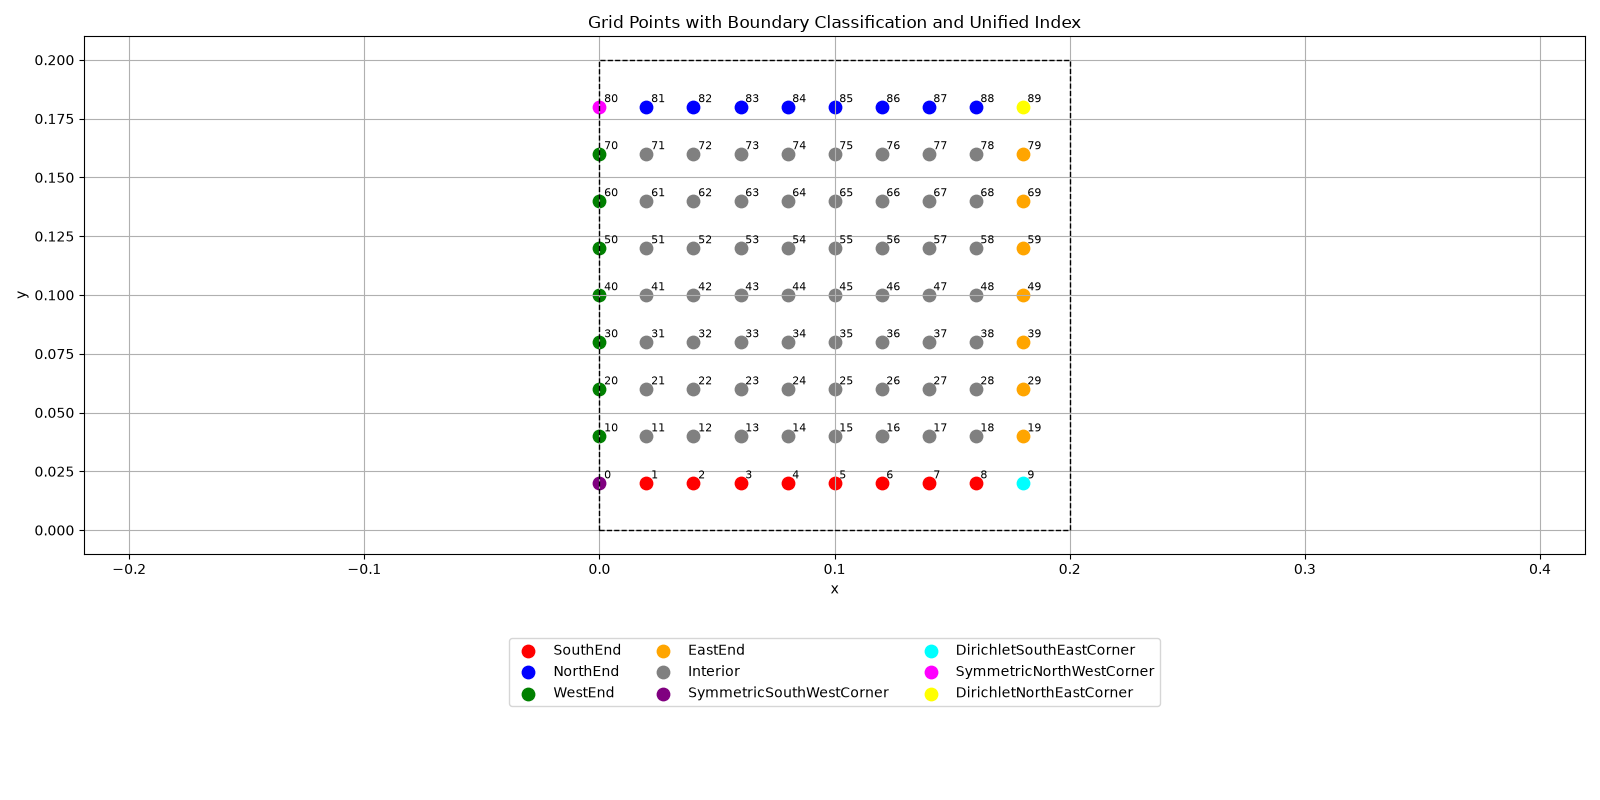

System Matrix is Generated. The shape of the system matrix is: (90, 90)
Temperature Vector is Generated. The shape of the temperature vector is: (90, 1)

                       FINITE DIFFERENCE PERFORMANCE REPORT — h = 0.020000 m                        

----------------------------------------------------------------------------------------------------
MESH INFORMATION
----------------------------------------------------------------------------------------------------
Domain length in x-direction                               : 0.200000 m
Domain length in y-direction                               : 0.200000 m
Computational domain area                                  : 0.040000 m^2

Requested mesh spacing, h                                  : 0.020000 m
Actual x-direction spacing, dx                             : 0.020000 m
Actual y-direction spacing, dy                             : 0.020000 m

Grid points in x-direction, nX                             : 11
Grid points in y-directio

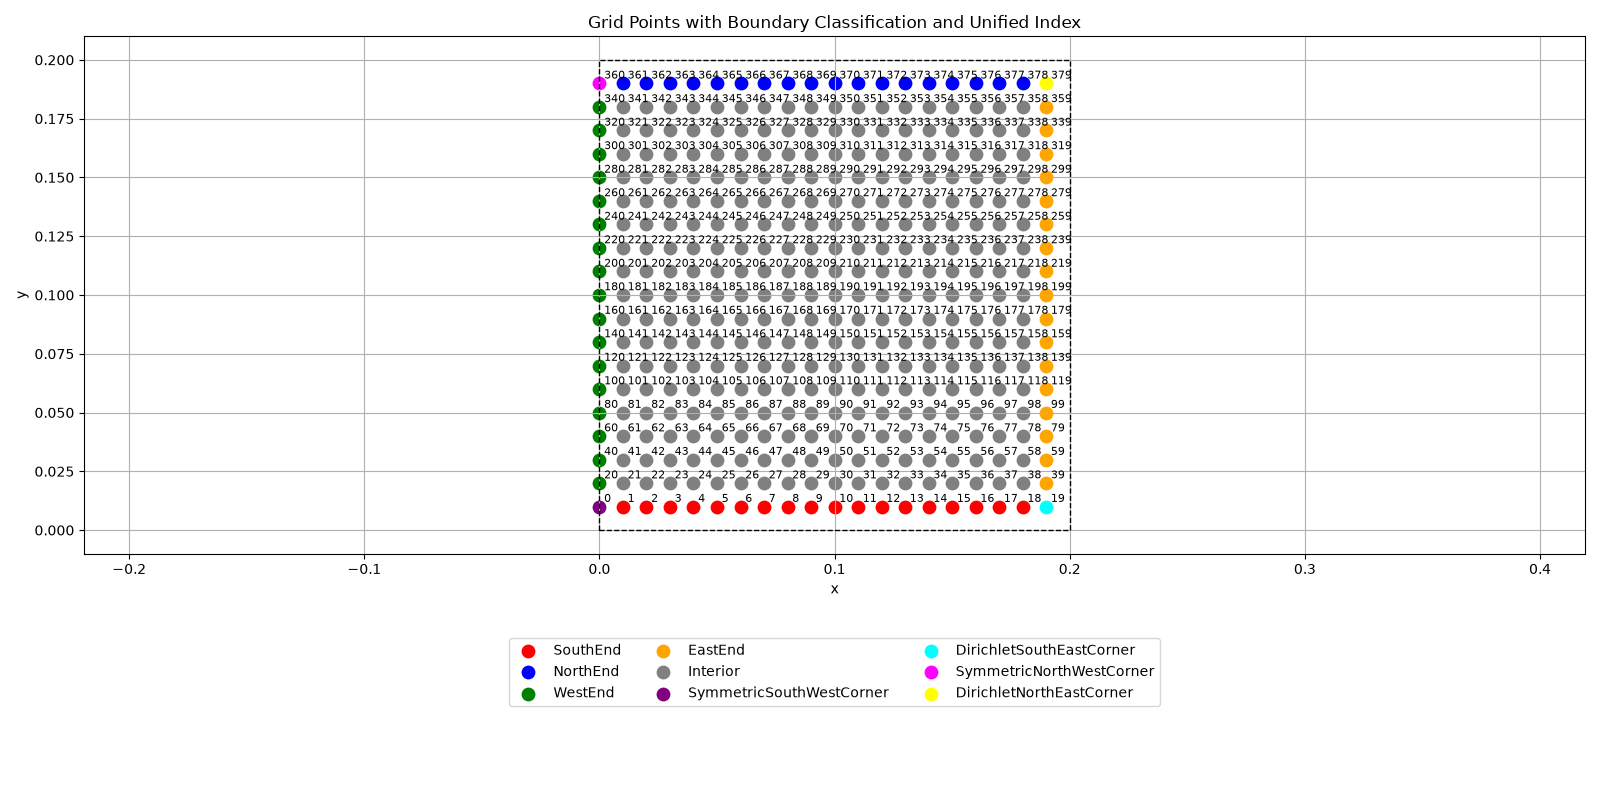

System Matrix is Generated. The shape of the system matrix is: (380, 380)
Temperature Vector is Generated. The shape of the temperature vector is: (380, 1)

                       FINITE DIFFERENCE PERFORMANCE REPORT — h = 0.010000 m                        

----------------------------------------------------------------------------------------------------
MESH INFORMATION
----------------------------------------------------------------------------------------------------
Domain length in x-direction                               : 0.200000 m
Domain length in y-direction                               : 0.200000 m
Computational domain area                                  : 0.040000 m^2

Requested mesh spacing, h                                  : 0.010000 m
Actual x-direction spacing, dx                             : 0.010000 m
Actual y-direction spacing, dy                             : 0.010000 m

Grid points in x-direction, nX                             : 21
Grid points in y-direc

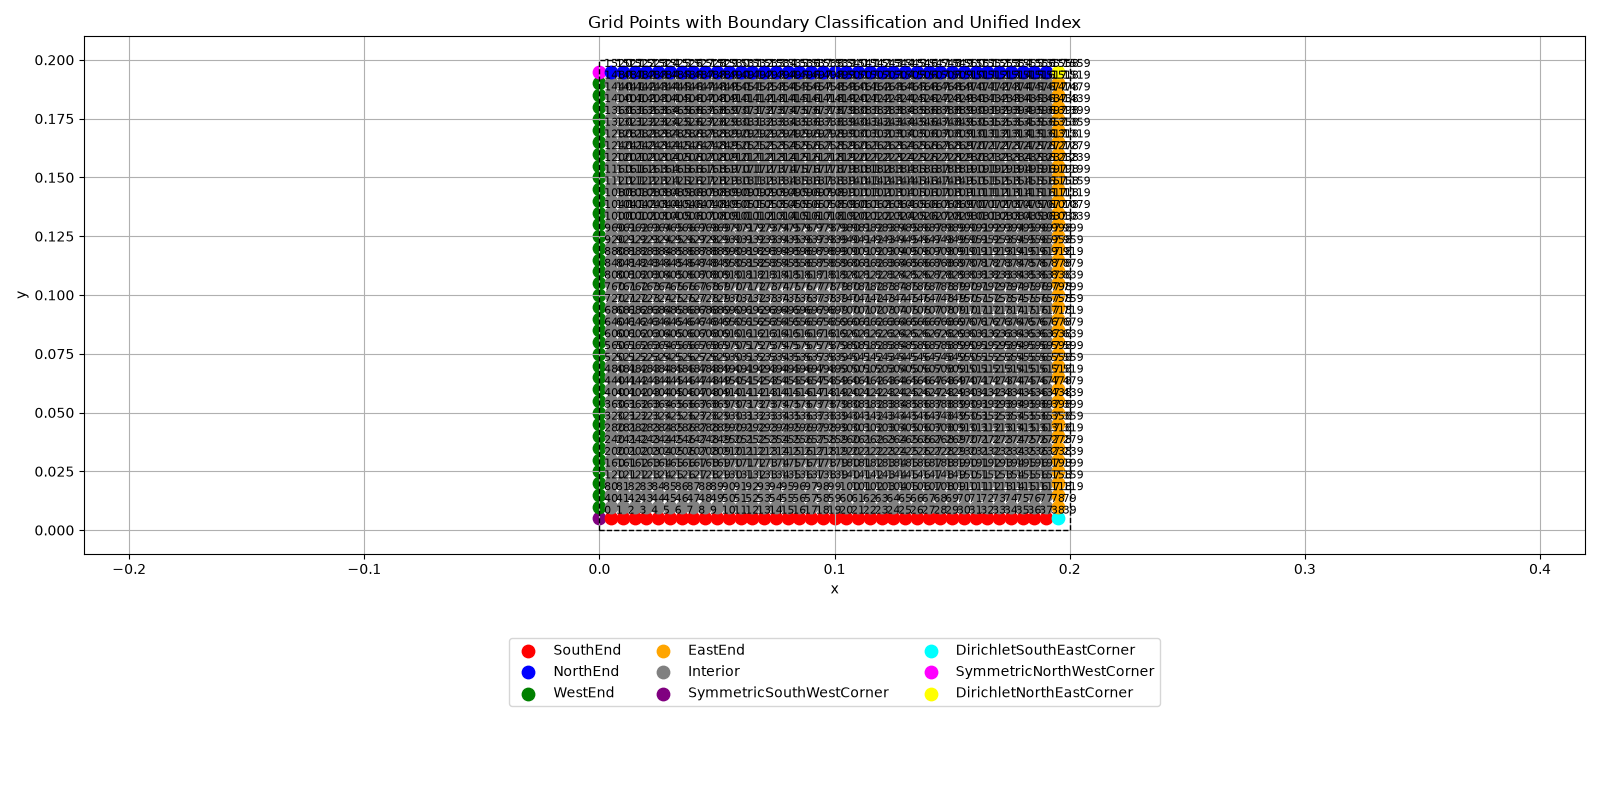

System Matrix is Generated. The shape of the system matrix is: (1560, 1560)
Temperature Vector is Generated. The shape of the temperature vector is: (1560, 1)

                       FINITE DIFFERENCE PERFORMANCE REPORT — h = 0.005000 m                        

----------------------------------------------------------------------------------------------------
MESH INFORMATION
----------------------------------------------------------------------------------------------------
Domain length in x-direction                               : 0.200000 m
Domain length in y-direction                               : 0.200000 m
Computational domain area                                  : 0.040000 m^2

Requested mesh spacing, h                                  : 0.005000 m
Actual x-direction spacing, dx                             : 0.005000 m
Actual y-direction spacing, dy                             : 0.005000 m

Grid points in x-direction, nX                             : 41
Grid points in y-di

In [8]:
import Logger
import importlib
importlib.reload(Logger)

meshStepSizes = [ 0.02, 0.01, 0.005 ]

# LU Decomposition and solving the system is done in the logger module. The results are stored in the MeshRefinementResults.txt.
# Lines 917 - 951 Implement the LU Decomposition Method for. This is was shifted to the logger since the Logger automates the solution process for a given mesh step size array.

meshRefinementResults = Logger.RunMeshRefinementStudy(
    a=a,
    b=b,
    meshStepSizes=meshStepSizes,
    MeshSetup=MeshSetup,
    MeshValidation=MeshValidation,
    GenerateSystemOfEquations=GenerateSystemOfEquations,
    notebookGlobals=globals(),
    RunMeshValidation=True
)

from contextlib import redirect_stdout
with open("../../Dumps/Problem1/MeshRefinementResults.txt", "w") as outputFile, redirect_stdout(outputFile):
    meshRefinementResults = Logger.RunMeshRefinementStudy(
        a=a,
        b=b,
        meshStepSizes=meshStepSizes,
        MeshSetup=MeshSetup,
        MeshValidation=MeshValidation,
        GenerateSystemOfEquations=GenerateSystemOfEquations,
        notebookGlobals=globals(),
        RunMeshValidation=False
    )

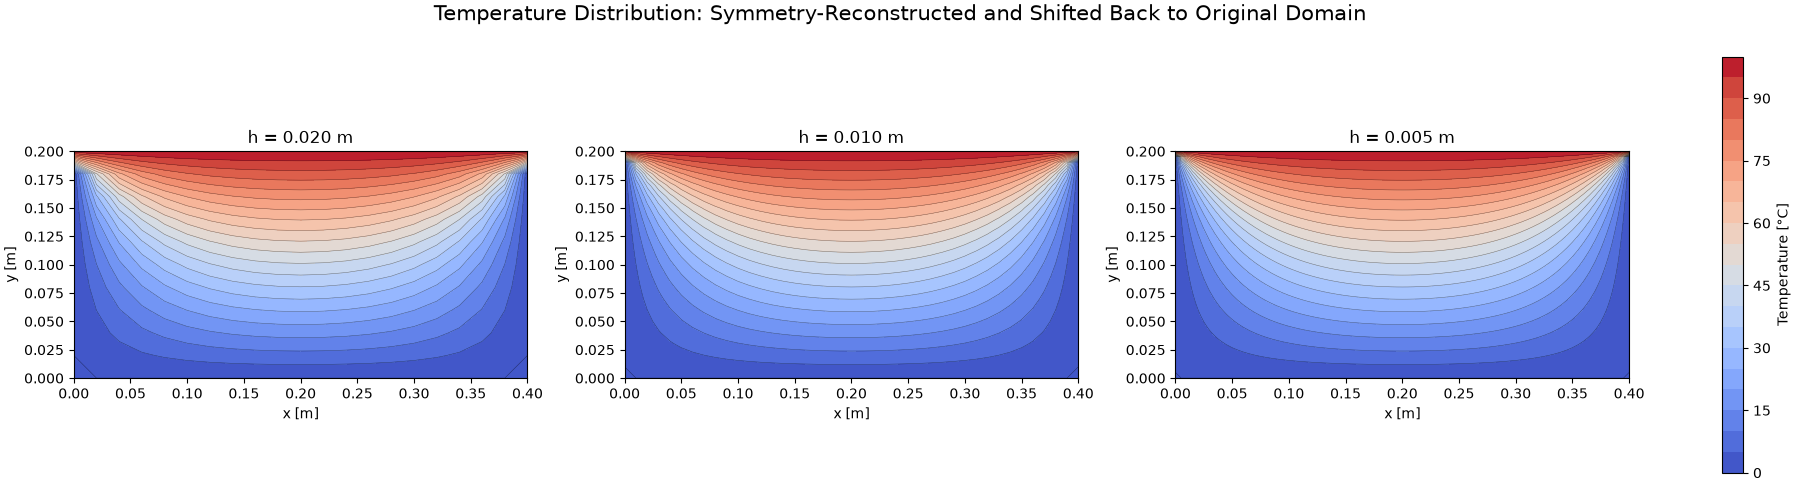

In [9]:
length, width, halfLength = 0.4, 0.2, 0.2
tNorthWall, tSouthWall, tEastWall, tWestWall = 100.0, 0.0, 0.0, 0.0

dumpPath = Path("../../Dumps/Problem1")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Common contour levels so all three plots use the same temperature scale
levels = np.linspace(0, 100, 21)

for axis, h in zip(axes, meshStepSizes):
    temperatureValues = np.loadtxt(dumpPath / f"TemperatureSolution_h_{h:.5f}.csv", delimiter=",", skiprows=1, usecols=1)
    xHalf = np.arange(0, halfLength, h)
    yInterior = np.arange(h, width, h)
    tHalfDomain = temperatureValues.reshape(len(yInterior), len(xHalf))

    # Mirror about physical symmetry plane x = 0.2 m
    xRight = halfLength + xHalf
    xInterior = np.concatenate((length - xRight[:0:-1], xRight))
    tInterior = np.concatenate((tHalfDomain[:, :0:-1], tHalfDomain), axis=1)

    # Add physical boundaries x = 0, x = 0.4, y = 0 and y = 0.2
    xFull = np.concatenate(([0.0], xInterior, [length]))
    yFull = np.concatenate(([0.0], yInterior, [width]))
    tFullDomain = np.zeros((len(yFull), len(xFull)))
    tFullDomain[1:-1, 1:-1] = tInterior

    # Boundary conditions
    tFullDomain[1:-1, 0] = tWestWall
    tFullDomain[1:-1, -1] = tEastWall
    tFullDomain[0, :] = tSouthWall
    tFullDomain[-1, :] = tNorthWall

    xFull, yFull = np.meshgrid(xFull, yFull)
    # 2D filled contour plot
    contour = axis.contourf(xFull, yFull, tFullDomain, levels=levels, cmap="coolwarm", vmin=0, vmax=100)

    # contour lines
    axis.contour(xFull, yFull, tFullDomain, levels=levels, colors="black", linewidths=0.35, alpha=0.5)

    axis.set_xlabel("x [m]")
    axis.set_ylabel("y [m]")
    axis.set_title(f"h = {h:.3f} m")
    axis.set_xlim(0, length)
    axis.set_ylim(0, width)
    # Preserve physical aspect ratio of the plate
    axis.set_aspect("equal")

# Shared colorbar
fig.colorbar(contour, ax=axes, label="Temperature [°C]", shrink=0.9)

fig.suptitle("Temperature Distribution: Symmetry-Reconstructed and Shifted Back to Original Domain", fontsize=15)

plt.show()

## Task C 
#### Comparison with Analytical Solution

In [10]:
import numpy as np

def AnalyticalSolution(x, y, a, b, T0, numberOfTerms):
    temperature = 0.0
    for termId in range(numberOfTerms):
        n = 2*termId + 1
        # This form avoids overflow for large values of n
        sinhRatio = np.exp((n*np.pi/a)*(y-b))*(1-np.exp(-2*n*np.pi*y/a))/(1-np.exp(-2*n*np.pi*b/a))
        temperature += (1/n)*np.sin(n*np.pi*x/a)*sinhRatio
    return (4*T0/np.pi)*temperature


def FindNumberOfTermsForConvergence(a, b, T0, h=0.005, tolerance=1e-5):
    # Use the smallest mesh because it has the largest number of comparison points
    xCoordinates = np.arange(h, a, h)
    yCoordinates = np.arange(h, b, h)
    numberOfTerms = 10
    while True:
        maximumAbsoluteError = 0.0
        maximumRelativeError = 0.0
        worstPoint = None
        # Check convergence at every interior point on the finest mesh
        for y in yCoordinates:
            for x in xCoordinates:
                previousTemperature = AnalyticalSolution(x, y, a, b, T0, numberOfTerms)
                currentTemperature = AnalyticalSolution(x, y, a, b, T0, numberOfTerms + 10)
                absoluteError = abs(currentTemperature-previousTemperature)
                relativeError = absoluteError/abs(currentTemperature) if abs(currentTemperature) > 1e-12 else 0.0
                # Store the largest error found on the mesh
                if absoluteError > maximumAbsoluteError:
                    maximumAbsoluteError = absoluteError
                    worstPoint = (x, y)
                if relativeError > maximumRelativeError:
                    maximumRelativeError = relativeError
        print(
            f"Terms: {numberOfTerms:3d} -> {numberOfTerms+10:3d} | "
            f"Max. Absolute Error: {maximumAbsoluteError:.8e} | "
            f"Max. Relative Error: {maximumRelativeError:.8e} | "
            f"Worst Point: ({worstPoint[0]:.3f}, {worstPoint[1]:.3f})"
        )
        # The series is considered converged when every point satisfies the tolerance
        if maximumAbsoluteError < tolerance:
            numberOfTerms += 10
            break

        numberOfTerms += 10

    print(f"\nAnalytical solution converged using {numberOfTerms} odd terms.")
    print(f"Highest value of n used = {2*numberOfTerms-1}")
    print(f"Maximum absolute error at convergence = {maximumAbsoluteError:.8e}")
    print(f"Maximum relative error at convergence = {maximumRelativeError:.8e}")

    return numberOfTerms

numberOfAnalyticalTerms = FindNumberOfTermsForConvergence(a=a, b=b, T0=tNorthWall, h=0.005, tolerance=1e-5)


Terms:  10 ->  20 | Max. Absolute Error: 4.06046696e+00 | Max. Relative Error: 8.07775410e-02 | Worst Point: (0.005, 0.195)
Terms:  20 ->  30 | Max. Absolute Error: 3.53399268e-01 | Max. Relative Error: 5.53533269e-03 | Worst Point: (0.010, 0.195)
Terms:  30 ->  40 | Max. Absolute Error: 6.71461961e-02 | Max. Relative Error: 1.34498402e-03 | Worst Point: (0.195, 0.195)
Terms:  40 ->  50 | Max. Absolute Error: 8.32477700e-03 | Max. Relative Error: 1.33066086e-04 | Worst Point: (0.010, 0.195)
Terms:  50 ->  60 | Max. Absolute Error: 1.79884330e-03 | Max. Relative Error: 3.60259633e-05 | Worst Point: (0.005, 0.195)
Terms:  60 ->  70 | Max. Absolute Error: 2.47468314e-04 | Max. Relative Error: 3.98523645e-06 | Worst Point: (0.010, 0.195)
Terms:  70 ->  80 | Max. Absolute Error: 5.63475412e-05 | Max. Relative Error: 1.12849453e-06 | Worst Point: (0.005, 0.195)
Terms:  80 ->  90 | Max. Absolute Error: 8.15179155e-06 | Max. Relative Error: 1.31803978e-07 | Worst Point: (0.010, 0.195)

Analyti

In [11]:
from scipy.interpolate import RegularGridInterpolator

fullLength = 2*a
fullWidth = b

comparisonPoints = [
    (fullLength/4, fullWidth/2),
    (fullLength/2, fullWidth/2),
    (3*fullLength/4, fullWidth/2),
    (fullLength/2, 3*fullWidth/4)
]

dumpPath = Path("../../Dumps/Problem1")

comparisonResults = []

for xPoint, yPoint in comparisonPoints:
    analyticalTemperature = AnalyticalSolution(xPoint, yPoint, fullLength, fullWidth, tNorthWall, numberOfAnalyticalTerms)
    rowResults = [xPoint, yPoint, analyticalTemperature]

    for h in meshStepSizes:
        temperatureValues = np.loadtxt(dumpPath/f"TemperatureSolution_h_{h:.5f}.csv", delimiter=",", skiprows=1, usecols=1)
        xHalf = np.arange(0, fullLength/2, h)
        yInterior = np.arange(h, fullWidth, h)
        temperatureHalf = temperatureValues.reshape(len(yInterior), len(xHalf))

        # Mirror the half-domain solution about x = a/2
        xRight = fullLength/2 + xHalf
        xInterior = np.concatenate((fullLength-xRight[:0:-1], xRight))
        temperatureFull = np.concatenate((temperatureHalf[:, :0:-1], temperatureHalf), axis=1)

        # Interpolate in case the requested point does not lie exactly on the mesh
        numericalInterpolator = RegularGridInterpolator((yInterior, xInterior), temperatureFull)
        numericalTemperature = float(numericalInterpolator((yPoint, xPoint)))
        absoluteError = abs(numericalTemperature-analyticalTemperature)
        rowResults.extend([numericalTemperature, absoluteError])

    comparisonResults.append(rowResults)

comparisonResults = np.array(comparisonResults)

print(f"{'x':>8}{'y':>8}{'Analytical':>14}{'h=0.020':>14}{'Error':>14}{'h=0.010':>14}{'Error':>14}{'h=0.005':>14}{'Error':>14}")
print("-"*114)

for row in comparisonResults:
    print(f"{row[0]:8.3f}{row[1]:8.3f}{row[2]:14.6f}{row[3]:14.6f}{row[4]:14.6e}{row[5]:14.6f}{row[6]:14.6e}{row[7]:14.6f}{row[8]:14.6e}")

       x       y    Analytical       h=0.020         Error       h=0.010         Error       h=0.005         Error
------------------------------------------------------------------------------------------------------------------
   0.100   0.100     36.405666     36.373679  3.198750e-02     36.397647  8.019647e-03     36.403660  2.006283e-03
   0.200   0.100     44.511510     44.418976  9.253433e-02     44.488087  2.342332e-02     44.505636  5.873986e-03
   0.300   0.100     36.405666     36.373679  3.198750e-02     36.397647  8.019647e-03     36.403660  2.006283e-03
   0.200   0.150     70.995329     70.961193  3.413612e-02     70.972786  2.254262e-02     70.989692  5.636675e-03


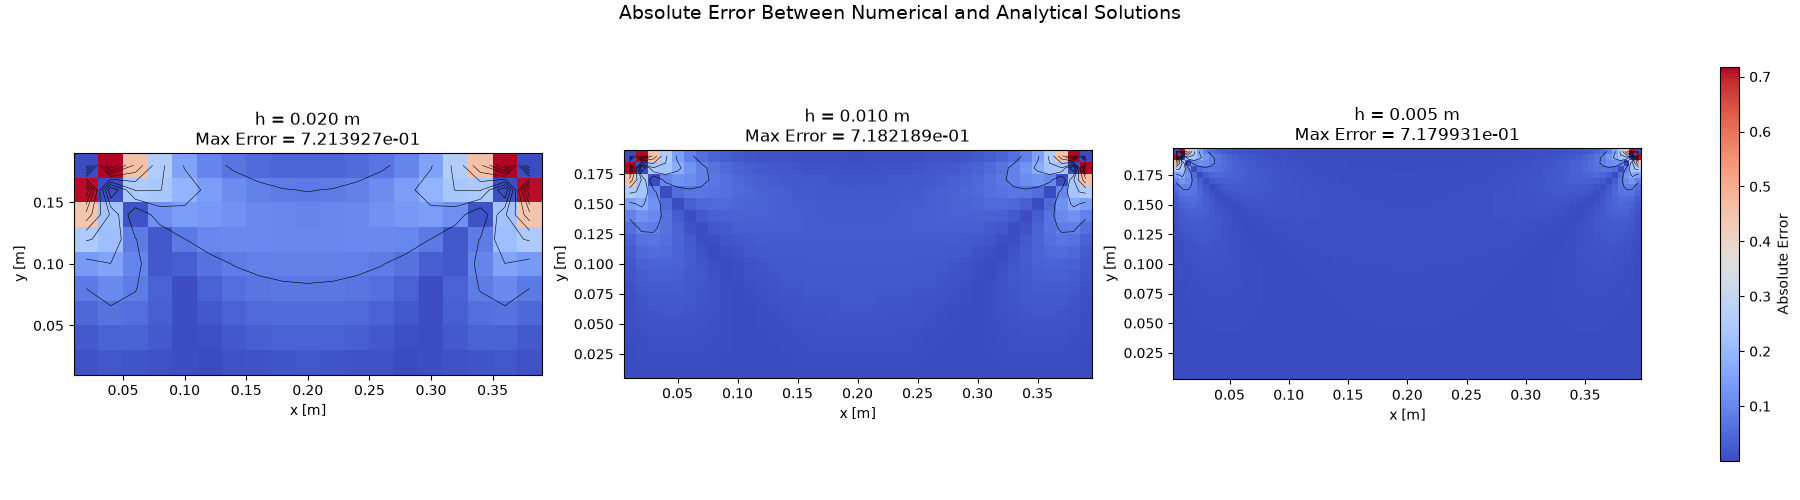

In [12]:
def AnalyticalSolution(x, y, a, b, T0, numberOfTerms):
    temperature = 0.0
    for termId in range(numberOfTerms):
        n = 2*termId + 1
        sinhRatio = np.exp((n*np.pi/a)*(y-b))*(1-np.exp(-2*n*np.pi*y/a))/(1-np.exp(-2*n*np.pi*b/a))
        temperature += (1/n)*np.sin(n*np.pi*x/a)*sinhRatio
    return (4*T0/np.pi)*temperature

fullLength, fullWidth, halfLength, T0 = 0.4, 0.2, 0.2, 100.0
meshStepSizes = [0.02, 0.01, 0.005]
dumpPath = Path("../../Dumps/Problem1")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for plotId, h in enumerate(meshStepSizes):
    numericalHalf = np.loadtxt(dumpPath / f"TemperatureSolution_h_{h:.5f}.csv", delimiter=",", skiprows=1, usecols=1)
    xHalf, yInterior = np.arange(0, halfLength, h), np.arange(h, fullWidth, h)
    THalf = numericalHalf.reshape(len(yInterior), len(xHalf))

    # Mirror the half-domain solution about x = 0.2 m to get the full interior field
    xRight = halfLength + xHalf
    xInterior = np.concatenate((fullLength - xRight[:0:-1], xRight))
    TNumerical = np.concatenate((THalf[:, :0:-1], THalf), axis=1)

    X, Y = np.meshgrid(xInterior, yInterior)

    # Compute analytical solution at the same interior points
    TAnalytical = np.zeros_like(TNumerical)
    for rowId in range(Y.shape[0]):
        for columnId in range(X.shape[1]):
            TAnalytical[rowId, columnId] = AnalyticalSolution(X[rowId, columnId], Y[rowId, columnId], fullLength, fullWidth, T0, numberOfAnalyticalTerms)

    absoluteError = np.abs(TNumerical - TAnalytical)

    heatMap = axes[plotId].pcolormesh(X, Y, absoluteError, shading="auto", cmap="coolwarm")
    contourLines = axes[plotId].contour(X, Y, absoluteError, colors="black", linewidths=0.4, levels=10)

    axes[plotId].set_title(f"h = {h:.3f} m\nMax Error = {np.max(absoluteError):.6e}")
    axes[plotId].set_xlabel("x [m]")
    axes[plotId].set_ylabel("y [m]")
    axes[plotId].set_aspect("equal")

fig.colorbar(heatMap, ax=axes, shrink=0.85, label="Absolute Error")
fig.suptitle("Absolute Error Between Numerical and Analytical Solutions", fontsize=14)
plt.show()